In [ ]:
pd.set_option('display.max_columns', None)  # Hiện tất cả thay vì ...
# Không cần chạy dòng này

# import thư viện và đọc file, lọc năm

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import RobustScaler
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import cross_val_score
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [3]:
accepted = pd.read_csv('/content/drive/MyDrive/Bài tập lớn/Khai phá dữ liệu/accepted_2007_to_2018Q4.csv', low_memory=False)

In [4]:
accepted.shape

(2260701, 151)

In [5]:
accepted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [6]:
# Chuyển issue_d sang dạng datetime
accepted['issue_d'] = pd.to_datetime(accepted['issue_d'], format='%b-%Y', errors='coerce')

In [7]:
accepted['year'] = accepted['issue_d'].dt.year
print("Dữ liệu từ năm:", accepted['year'].min(), "đến năm:", accepted['year'].max())

Dữ liệu từ năm: 2007.0 đến năm: 2018.0


# Tiền xử lý

In [8]:
data = accepted.copy()

### *Lọc dòng, cột*

In [9]:
# Lọc những dòng có đúng 1 giá trị
cnt_value_by_row = data.notna().sum(axis=1)       # axis=1 là đếm trên dòng, =0 là đếm trên cột
missing_row = data[cnt_value_by_row == 1]

data.drop(missing_row.index, inplace=True)        # Xóa đi

In [ ]:
print(data.isna().sum())
# Không chạy dòng này

id                                                  0
member_id                                     2260668
loan_amnt                                           0
funded_amnt                                         0
funded_amnt_inv                                     0
term                                                0
int_rate                                            0
installment                                         0
grade                                               0
sub_grade                                           0
emp_title                                      166969
emp_length                                     146907
home_ownership                                      0
annual_inc                                          4
verification_status                                 0
issue_d                                             0
loan_status                                         0
pymnt_plan                                          0
url                         

In [10]:
missing_column = data.isna().sum()[data.isna().sum() > 1000000]   # Lọc những cột thiếu hơn 1 triệu dòng
data.drop(columns=missing_column.index, inplace=True)

In [11]:
# Lọc chay
data.drop(['id','emp_title','issue_d','pymnt_plan','url','title','zip_code','addr_state',
         'out_prncp','out_prncp_inv','total_pymnt','total_pymnt_inv',
         'total_rec_prncp','total_rec_int','total_rec_late_fee','recoveries',
         'collection_recovery_fee','last_pymnt_d','last_pymnt_amnt','last_credit_pull_d',
         'last_fico_range_high','last_fico_range_low','collections_12_mths_ex_med',
         'tot_cur_bal','open_acc_6m','open_act_il', 'inq_fi',
         'open_il_24m','total_bal_il','all_util', 'int_rate', 'sub_grade',
         'total_cu_tl','inq_last_12m','acc_open_past_24mths','chargeoff_within_12_mths',
         'delinq_amnt','mths_since_recent_bc','mths_since_recent_inq','num_accts_ever_120_pd',
         'tax_liens','hardship_flag', 'funded_amnt', 'funded_amnt_inv', 'application_type',
         'disbursement_method','grade','num_bc_tl', 'delinq_2yrs',
         'mo_sin_old_il_acct', 'revol_bal', 'tot_coll_amt',
         'mo_sin_old_rev_tl_op','mo_sin_rcnt_rev_tl_op',
         'num_actv_rev_tl','num_bc_sats','debt_settlement_flag',
         'total_acc','num_il_tl','num_op_rev_tl','num_rev_accts','num_rev_tl_bal_gt_0','num_sats',
         'num_tl_120dpd_2m','num_tl_30dpd','num_tl_90g_dpd_24m',
         'initial_list_status', 'policy_code','bc_open_to_buy', 'bc_util',
         'total_il_high_credit_limit', 'tot_hi_cred_lim','fico_range_high',
         'installment','open_rv_24m','max_bal_bc','pub_rec',
         'open_il_12m', 'mths_since_rcnt_il', 'open_rv_12m'],
          axis=1, inplace=True)


In [12]:
data.shape

(2260668, 27)

In [13]:
data.columns

Index(['loan_amnt', 'term', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'loan_status', 'purpose', 'dti',
       'earliest_cr_line', 'fico_range_low', 'inq_last_6mths', 'open_acc',
       'revol_util', 'acc_now_delinq', 'total_rev_hi_lim', 'avg_cur_bal',
       'mo_sin_rcnt_tl', 'mort_acc', 'num_actv_bc_tl', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'total_bal_ex_mort', 'total_bc_limit', 'year'],
      dtype='object')

### Giữ lại 2 thuộc tính

In [14]:
data['loan_status'].value_counts()

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


In [15]:
# Chỉ lấy 2 thuộc tính giúp dự đoán
# Fully Paid: đã thanh toán, Charged Off: vỡ nợ
data = data[(data['loan_status'] == 'Fully Paid') | (data['loan_status'] == 'Charged Off')]

In [16]:
data.shape

(1345310, 27)

In [17]:
data = data[(data['year'] >= 2013) & (data['year'] <= 2018)].copy()

In [18]:
he = data.copy()

In [19]:
he.drop(columns=['year'], inplace=True)

In [20]:
he.shape

(1252157, 26)

In [21]:
he.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1252157 entries, 0 to 2260697
Data columns (total 26 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   loan_amnt             1252157 non-null  float64
 1   term                  1252157 non-null  object 
 2   emp_length            1176649 non-null  object 
 3   home_ownership        1252157 non-null  object 
 4   annual_inc            1252157 non-null  float64
 5   verification_status   1252157 non-null  object 
 6   loan_status           1252157 non-null  object 
 7   purpose               1252157 non-null  object 
 8   dti                   1251783 non-null  float64
 9   earliest_cr_line      1252157 non-null  object 
 10  fico_range_low        1252157 non-null  float64
 11  inq_last_6mths        1252156 non-null  float64
 12  open_acc              1252157 non-null  float64
 13  revol_util            1251397 non-null  float64
 14  acc_now_delinq        1252157 non-null 

### *Mã hóa biến object (encoding)*

In [22]:
# gán nhãn cho biến đầu ra
he['loan_status'] = he['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

In [23]:
he['term'] = he['term'].map({' 36 months': 0, ' 60 months': 1})

# gán số cho kn đi làm
he['emp_length'] = he['emp_length'].map({
    '10+ years': 10, '2 years': 2, '< 1 year': 0, '3 years': 3,'1 year': 1,
    '5 years': 5,'4 years': 4,'6 years': 6,'8 years': 8,'7 years': 7,'9 years': 9
})

In [24]:
# Cái này ko encoding nữa, thử gán số thôi
he['home_ownership'] = he['home_ownership'].map({
    'MORTGAGE': 0, 'RENT': 1, 'OWN': 2, 'ANY': 3, 'NONE': 4
})

In [25]:
# Xác minh thu nhập, encoding
he['verification_status'] = he['verification_status'].map({
    'Not Verified': 0,        # Chưa được xác minh
    'Verified': 1,            # Xác minh bởi người vay (qua giấy tờ)
    'Source Verified': 2      # Xác minh bởi bên thứ 3 (uy tín +1)
})

In [26]:
he['earliest_cr_line'] = pd.to_datetime(he['earliest_cr_line'], format='%b-%Y', errors='coerce')
latest_date = he['earliest_cr_line'].max()
# Tính số năm kể từ ngày mở tài khoản tín dụng đầu tiên
he['earliest_cr_line'] = (latest_date - he['earliest_cr_line']).dt.days / 365.25

####`purpose`

In [27]:
he['purpose'].value_counts()

,count
purpose,
debt_consolidation,730834
credit_card,279777
home_improvement,81626
other,70821
major_purchase,25877
medical,14229
small_business,12199
car,12133
moving,8498


In [28]:
# Ghép nhóm với nhau để giảm số trạng thái (có cái ít qá):
# home_improvement + house
# major_purchase + car
# medical
# moving + vacation
# education + wedding + renewable_energy = other

In [29]:
def group_purpose(purpose):
    if purpose == 'debt_consolidation':
        return 'debt_consolidation'     # 730834
    elif purpose in ['credit_card']:
        return 'credit_card'            # 279777
    if purpose in ['home_improvement', 'house']:
        return 'house'                  # 88079
    # Mua đồ có giá trị lớn
    elif purpose in ['major_purchase', 'car']:
        return 'major_purchase'         # 38010
    elif purpose == 'medical':
        return 'medical'
    elif purpose == 'small_business':
        return 'small_bussiness'
    elif purpose in ['moving', 'vacation']:
        return 'moving'
    else:
        return 'other'

he['purpose_grp'] = he['purpose'].apply(group_purpose)

In [30]:
he['purpose_grp'].value_counts()

,count
purpose_grp,
debt_consolidation,730834
credit_card,279777
house,88079
other,72191
major_purchase,38010
moving,16838
medical,14229
small_bussiness,12199


In [31]:
he['purpose_grp'] = he['purpose_grp'].map({
    'debt_consolidation': 1,
    'credit_card': 2,
    'house': 3,
    'other': 4,
    'major_purchase': 5,
    'moving': 6,
    'medical': 7,
    'small_bussiness': 8
})

In [32]:
he['purpose'] = he['purpose_grp']

In [33]:
he.drop(columns=['purpose_grp'], inplace=True)

In [34]:
# 8 - small_business
# 7 - medical
# 6 - credit
# 5 - major_purchase
# 4 - house
# 3 - debt
# 2 - other
# 1 - moving

In [35]:
# def group_purpose_grp (purpose_grp):
#   if purpose_grp == 'small_business':
#     return 8
#   elif purpose_grp == 'medical':
#     return 7
#   elif purpose_grp == 'credit_card':
#     return 6
#   elif purpose_grp == 'major_purchase':
#     return 5
#   elif purpose_grp == 'house':
#     return 4
#   elif purpose_grp == 'debt_consolidation':
#     return 3
#   elif purpose_grp == 'other':
#     return 2
#   else:
#     return 1

# df['purpose'] = df['purpose_grp'].apply(group_purpose_grp)

####Kiểm tra tính tương quan giữa các biến

In [36]:
he.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1252157 entries, 0 to 2260697
Data columns (total 26 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   loan_amnt             1252157 non-null  float64
 1   term                  1252157 non-null  int64  
 2   emp_length            1176649 non-null  float64
 3   home_ownership        1252157 non-null  int64  
 4   annual_inc            1252157 non-null  float64
 5   verification_status   1252157 non-null  int64  
 6   loan_status           1252157 non-null  int64  
 7   purpose               1252157 non-null  int64  
 8   dti                   1251783 non-null  float64
 9   earliest_cr_line      1252157 non-null  float64
 10  fico_range_low        1252157 non-null  float64
 11  inq_last_6mths        1252156 non-null  float64
 12  open_acc              1252157 non-null  float64
 13  revol_util            1251397 non-null  float64
 14  acc_now_delinq        1252157 non-null 

In [37]:
# Kiểm tra tính tương quan giữa các biến
c = he.corr().abs()

unstack_corr = c.unstack()

pairs = unstack_corr.sort_values(ascending=False)

corr_pairs = pd.DataFrame(pairs).drop_duplicates().reset_index()
corr_pairs.columns = ['feature1', 'feature2', 'corr']

cond1 = (corr_pairs.feature1 != corr_pairs.feature2)
cond2 = (corr_pairs['corr'] > 0.80)

corr_pairs_filtered = corr_pairs[cond1 & cond2]
corr_pairs_filtered

# Kết quả là ko có biến nào tương quan hết, 10đ (có tương quan thì ném lên chỗ lọc biến r nhé :> )

,feature1,feature2,corr


### *Xử lý các dòng thiếu*

In [38]:
he.shape

(1252157, 26)

In [39]:
print(he.isna().sum()[he.isna().sum() > 0])

emp_length          75508
dti                   374
inq_last_6mths          1
revol_util            760
avg_cur_bal            22
pct_tl_nvr_dlq        154
percent_bc_gt_75    13750
dtype: int64


In [40]:
# Điền 0 vào những người vay có emp_length (số năm đi làm)
he['emp_length'] = he['emp_length'].fillna(0)

In [41]:
# Vì số lượng thiếu quá ít nên điền là trung vị
he['dti'] = he['dti'].fillna(he['dti'].median())

In [42]:
# df[df['inq_last_6mths'].isna() == True]
he.at[1099335, 'inq_last_6mths'] = 0.0

In [43]:
# Biến này chưa rõ NaN là lí do vì sao -> điền trung vị cho an toàn
he['revol_util'] = he['revol_util'].fillna(he['revol_util'].median())

In [44]:
# trung bình số dư đang có
# Vì tỉ lệ thiếu quá nhỏ (~0.0018%) nên điền median
he['avg_cur_bal'] = he['avg_cur_bal'].fillna(he['avg_cur_bal'].median())

In [45]:
# Tỷ lệ các tài khoản chưa từng bị trễ hạn.
# = (số tài khoản chưa trễ hạn / tổng số tài khoản) * 100.

# Khách hàng chưa có khoản vay nào trước đó => điền 100.0
he['pct_tl_nvr_dlq'] = he['pct_tl_nvr_dlq'].fillna(100.0)

In [46]:
# Tỷ lệ tài khoản thẻ tín dụng có mức sử dụng > 75% hạn mức
# 0.0 là tốt, 100.0 là xấu
# Điền NA là 0, có thể vì là khách chưa có khoản vay nào
he.loc[:, 'percent_bc_gt_75'] = he['percent_bc_gt_75'].fillna(0.0)

In [47]:
he.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1252157 entries, 0 to 2260697
Data columns (total 26 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   loan_amnt             1252157 non-null  float64
 1   term                  1252157 non-null  int64  
 2   emp_length            1252157 non-null  float64
 3   home_ownership        1252157 non-null  int64  
 4   annual_inc            1252157 non-null  float64
 5   verification_status   1252157 non-null  int64  
 6   loan_status           1252157 non-null  int64  
 7   purpose               1252157 non-null  int64  
 8   dti                   1252157 non-null  float64
 9   earliest_cr_line      1252157 non-null  float64
 10  fico_range_low        1252157 non-null  float64
 11  inq_last_6mths        1252157 non-null  float64
 12  open_acc              1252157 non-null  float64
 13  revol_util            1252157 non-null  float64
 14  acc_now_delinq        1252157 non-null 

In [48]:
df = he.copy()

In [49]:
df.columns

Index(['loan_amnt', 'term', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'loan_status', 'purpose', 'dti',
       'earliest_cr_line', 'fico_range_low', 'inq_last_6mths', 'open_acc',
       'revol_util', 'acc_now_delinq', 'total_rev_hi_lim', 'avg_cur_bal',
       'mo_sin_rcnt_tl', 'mort_acc', 'num_actv_bc_tl', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'total_bal_ex_mort', 'total_bc_limit'],
      dtype='object')

### Kiểm tra tính tuyến tính
>**Vì mô hình muốn chạy tốt thì các biến phải tuyến tính**
<br>(Đồ thị càng thẳng thì càng tuyến tính)

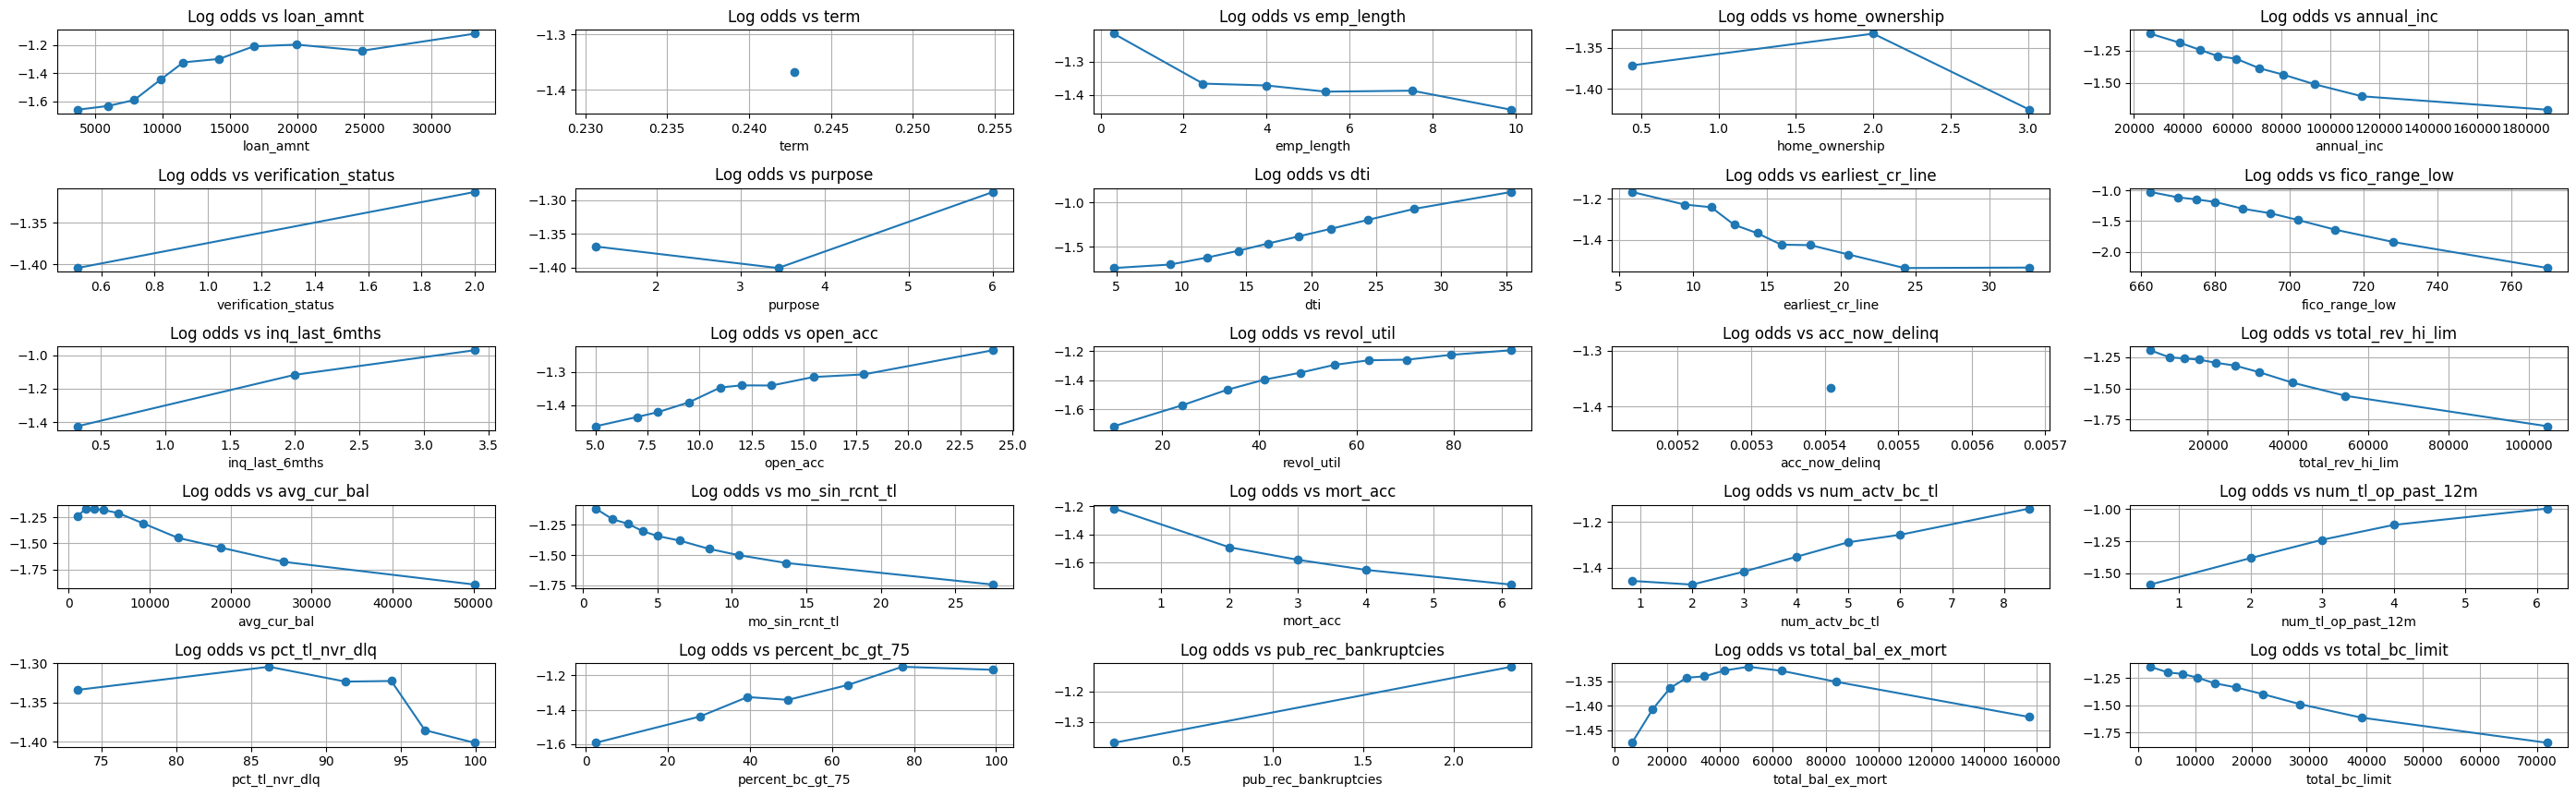

In [50]:
numeric_features = [
    'loan_amnt', 'term', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'purpose', 'dti',
    'earliest_cr_line', 'fico_range_low', 'inq_last_6mths', 'open_acc',
    'revol_util', 'acc_now_delinq', 'total_rev_hi_lim',
    'avg_cur_bal', 'mo_sin_rcnt_tl', 'mort_acc', 'num_actv_bc_tl',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'pub_rec_bankruptcies', 'total_bal_ex_mort', 'total_bc_limit'
]

n_bins = 10
temp_df = df.copy()

plt.figure(figsize=(28, 10))

for i, feature in enumerate(numeric_features, 1):
    try:
        # Chia bin theo phần trăm
        temp_df['bin'] = pd.qcut(temp_df[feature], q=n_bins, duplicates='drop')

        # Tính tỷ lệ default (giả sử loan_status = 1 là default)
        grouped = temp_df.groupby('bin', observed=True)['loan_status'].mean()
        log_odds = np.log(grouped / (1 - grouped))

        bin_centers = temp_df.groupby('bin', observed=True)[feature].mean()

        # Vẽ biểu đồ
        plt.subplot(6, 5, i)  # 6 hàng, 5 cột
        plt.plot(bin_centers, log_odds, marker='o')
        plt.xlabel(feature)
        plt.title(f'Log odds vs {feature}')
        plt.grid(True)
    except Exception as e:
        print(f"Lỗi với biến {feature}: {e}")

plt.tight_layout()
plt.show()

**Bảng đánh giá tính tuyến tính**

|STT |Tên biến             | Tuyến tính|
|:---|:--------------------|:------|
|1   |loan_amnt            | tạm|
|2   |term                 |
|3   |emp_length           | tạm|
|4   |home_ownership       |
|5   |annual_inc           | ✔|
|6   |verification_status  | ✔|
|7   |purpose              |
|8   |dti                  | ✔|
|9   |delinq_2yrs          | ✔|
|10  |earliest_cr_line     | tạm|
|11  |fico_range_low       | ✔|
|12  |inq_last_6mths       | ✔|
|13  |open_acc             | ✔|
|14  |revol_util           | ✔|
|15  |acc_now_delinq       |
|16  |total_rev_hi_lim     | ✔|
|17  |avg_cur_bal          | ✔|
|18  |mo_sin_rcnt_tl       | ✔|
|19  |mort_acc             | ✔|
|20  |num_actv_bc_tl       | ✔|
|21  |num_tl_op_past_12m   | ✔|
|22  |pct_tl_nvr_dlq       |
|23  |percent_bc_gt_75     | tạm|
|24  |pub_rec_bankruptcies | ✔|
|25  |total_bal_ex_mort    |
|26  |total_bc_limit       | ✔|


In [51]:
# Xóa tiếp những biến không tuyến tính
df.drop(columns=['term', 'home_ownership', 'purpose', 'acc_now_delinq',
                 'pct_tl_nvr_dlq', 'total_bal_ex_mort'], inplace=True)

In [53]:
df.shape

(1252157, 20)

### **-- Ý nghĩa biến --**

|Tên biến             |Ý nghĩa| Loại biến| Tuyến tính|
|:--------------------|:------|:---------|:----------|
|loan_amnt            | số tiền vay| | tạm|
|emp_length           | số năm làm việc| Rời rạc | tạm|
|annual_inc           | lương hàng năm| | ✔|
|verification_status  | trạng thái xác minh thu nhập|Rời rạc| ✔|
|dti                  | tỉ lệ nợ / thu nhập (%)| | ✔|
|delinq_2yrs          | số lần bị trễ hạn thanh toán từ 30 ngày trở lên trong 2 năm gần đây| Rời rạc | ✔|
|earliest_cr_line     | thời điểm mở tk tín dụng đầu tiên| | tạm|
|fico_range_low       | điểm tín dụng| | ✔|
|inq_last_6mths       | số lần bị tra cứu tín dụng trong 6 tháng gần đây| Rời rạc| ✔|
|open_acc             | số lượng tk tín dụng còn hoạt động| | ✔|
|revol_util           | sử dụng bao nhiêu % hạn mức| | ✔|
|total_rev_hi_lim     | tổng hạn mức tín dụng trên all tk| | ✔|
|avg_cur_bal          | tổng số dư nợ / số tk đang mở| | ✔|
|mo_sin_rcnt_tl       | số tháng kể từ lần mở tk tín dụng gần nhất| | ✔|
|mort_acc             | số lượng tài khoản thế chấp| Rời rạc| ✔|
|num_actv_bc_tl       | số lượng tk đang hoạt động| | ✔|
|num_tl_op_past_12m   | số tk mới mở trong 12 tháng gần đây| | ✔|
|percent_bc_gt_75     | % tk sử dụng >75% hạn mức|| tạm|
|pub_rec_bankruptcies | số lần phá sản|| ✔|
|total_bc_limit       | tổng hạn mức của all thẻ ngân hàng| | ✔|

>Biến rời rạc không cần phải chuẩn hóa

### *Ngoại lai*
*-> Vấn đề: nếu làm Robust thì có thể cái người thu nhập **KÉM** sẽ bị đè xuống để cân bằng*

*(cô bảo cái nào cũng có vấn đề cả, qtrong là mình hiểu vì sao làm vậy)*

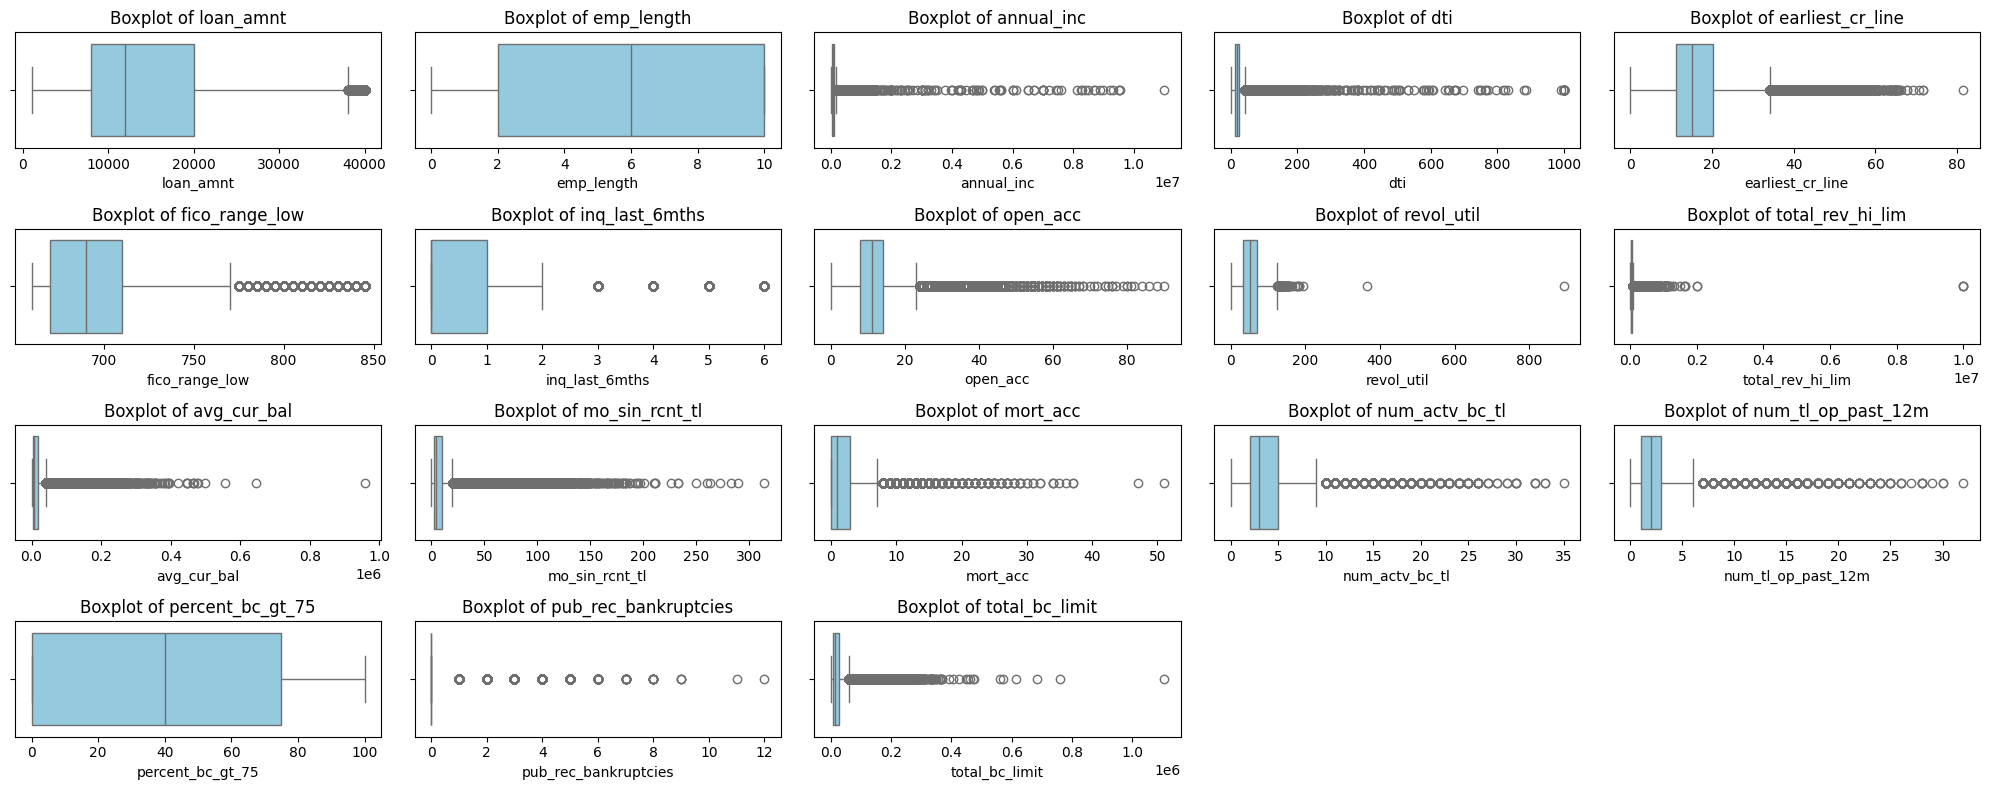

In [54]:
cols_to_check = [
    'loan_amnt', 'emp_length', 'annual_inc', 'dti', 'earliest_cr_line',
    'fico_range_low', 'inq_last_6mths', 'open_acc', 'revol_util',
    'total_rev_hi_lim', 'avg_cur_bal', 'mo_sin_rcnt_tl', 'mort_acc', 'num_actv_bc_tl',
    'num_tl_op_past_12m', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'total_bc_limit'
]

plt.figure(figsize=(20, 8))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(4, 5, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [55]:
# Hàm kiểm tra ngoại lai của từng biến
def outliers(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  low = Q1 - 1.5 * IQR
  high = Q3 + 1.5 * IQR

  print(f"Q1: {Q1}")
  print(f"Q2: {Q3}")
  print(f"Ngưỡng dưới: ", low)
  print(f"Ngưỡng trên: ", high)

In [56]:
# Hàm vẽ boxplot cho từng biến
def box(df, col):
  plt.figure(figsize=(7, 1))
  sns.boxplot(x=df[col])
  plt.show()

In [57]:
dete = df.copy()

In [58]:
df = dete.copy()

In [59]:
df.shape

(1252157, 20)

Cái nào ✅ là không đổi cách làm nữa

######**`pub_rec_bankruptcies`** ✅
số lần phá sản công khai -> là biến liên tục

thông thường phá sản lần đầu thì có thể châm chước, nhưng phá lần 2 thì hên xui, rủi ro cao

Do đó, mô hình chỉ nên dự đoán trên tập khách hàng mà ngân hàng ***thực sự cân nhắc cho vay*** – giúp tăng tính thực tiễn cho mô hình

In [60]:
pub_rec_99 = np.percentile(df['pub_rec_bankruptcies'], 99)

print(f"99% KH có số lần phá sản ≤ {pub_rec_99:,} lần")

99% KH có số lần phá sản ≤ 1.0 lần


In [61]:
df = df[df['pub_rec_bankruptcies'] <= 1.0]

# Chỉ phân tích nhóm df1, phá sản đến lần thứ 2 thì khả năng vỡ nợ cao vl

###### **`loan_amnt`** ✅

In [62]:
print(f"99% ≤ {np.percentile(df['loan_amnt'], 99):,}")

99% ≤ 35,000.0


In [63]:
outliers(df, 'loan_amnt')

Q1: 8000.0
Q2: 20000.0
Ngưỡng dưới:  -10000.0
Ngưỡng trên:  38000.0


In [64]:
df = df[df['loan_amnt'] <= 38000.0]

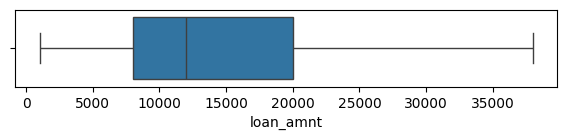

In [65]:
box(df, 'loan_amnt')

######**`annual_inc`** ✅
(ko thể log)

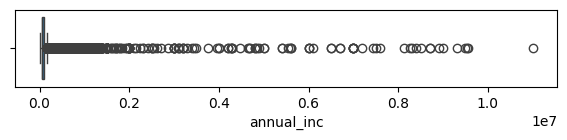

In [141]:
box(df, 'annual_inc')

In [66]:
income_99 = np.percentile(df['annual_inc'], 99)

print(f"99% KH có lương ≤ {income_99:,} USD")

99% KH có lương ≤ 250,000.0 USD


In [67]:
# Tách nhóm bình thường và giàu
df_normal = df[(df['annual_inc'] <= income_99)].copy()
df_rich = df[(df['annual_inc'] > income_99)].copy()

print(f"Số khách hàng thường: {len(df_normal):,}")
print(f"Số khách hàng giàu: {len(df_rich):,}")

df = df_normal.copy()

Số khách hàng thường: 1,222,976
Số khách hàng giàu: 12,095


<Axes: xlabel='annual_inc', ylabel='Count'>

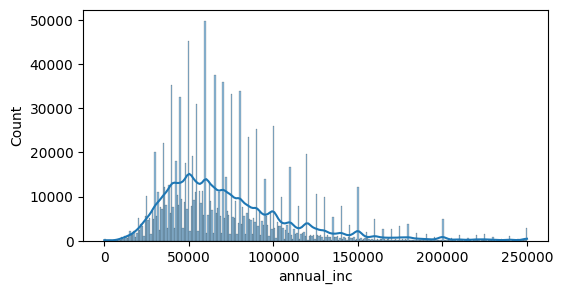

In [144]:
plt.figure(figsize=(6, 3))
sns.histplot(df['annual_inc'], kde=True)

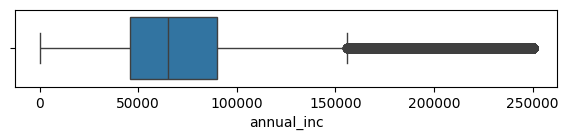

In [145]:
box(df, 'annual_inc')

######**`dti`** ✅

In [68]:
print(df['dti'].min())        # -1.0
# dti là biến tỉ lệ nợ / thu nhập, không thể nào là số âm => loại
print(df['dti'].max())        # 999.0
# Siêu bất thường, nếu tỉ lệ > 100 chứng tỏ KH đang có nợ lớn hơn thu nhập => lọc
df = df[(df['dti'] >= 0) & (df['dti'] <= 100)]

-1.0
999.0


In [69]:
print(f"99% ≤ {np.percentile(df['dti'], 99):,}")

99% ≤ 38.55


Tìm hiểu nghiệp vụ:

* DTI < 36%  : có khả năng thanh toán nợ
* 37% - 42%  : cần cân nhắc khi tiếp tục gia tăng thêm các khoản nợ mới
* 43% - 49%  : nợ cao hơn mức thu nhập, dễ gặp rủi ro tín dụng. có thể cân nhắc từ chối khoản vay hoặc yêu cầu lãi suất cao hơn
* DTI > 50%  : mức báo động

In [70]:
# Trên 50 là báo động r thì ngta sẽ xét riêng, còn mih xét dưới 50
df = df[df['dti'] < 50.0]

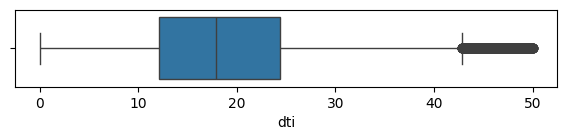

In [149]:
box(df, 'dti')

######**`earliest_cr_line`** ✅
không log

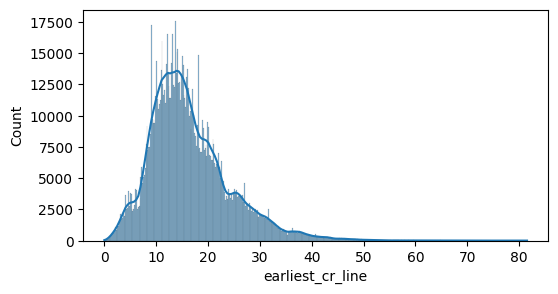

In [71]:
plt.figure(figsize=(6, 3))
sns.histplot(df['earliest_cr_line'], kde=True)
plt.show()

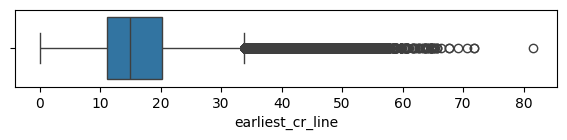

In [72]:
plt.figure(figsize=(7, 1))
sns.boxplot(x=df['earliest_cr_line'])
plt.show()

In [73]:
# Bỏ cái ngoại lai tách biệt kia đi
df = df[df['earliest_cr_line'] < 80]

In [74]:
e_99 = np.percentile(df['earliest_cr_line'], 99)

print(f"99% ≤ {e_99:,}")

99% ≤ 40.082135523613964


In [75]:
df = df[df['earliest_cr_line'] <= e_99]

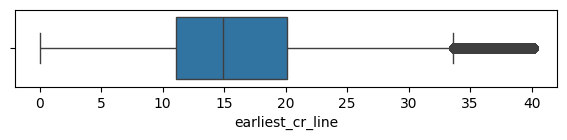

In [76]:
box(df, 'earliest_cr_line')

######**`fico_range_low`** ✅
Ko log

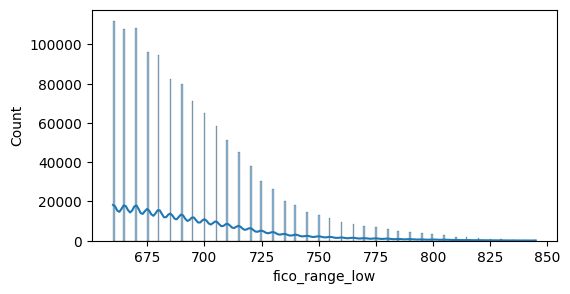

In [77]:
plt.figure(figsize=(6, 3))
sns.histplot(df['fico_range_low'], kde=True)
plt.show()

Tìm hiểu nghiệp vụ (từ myFICO):

|  |  |
|:--------|:----
|< 580    |Poor
|580 - 669|Fair  
|670 - 739|Good         
|740 - 799|Very gud      
| 800+    |Exceptional   

In [78]:
fico_99 = np.percentile(df['fico_range_low'], 99)

print(f"99% KH có fico ≤ {fico_99:,}")

99% KH có fico ≤ 800.0


In [79]:
outliers(df, 'fico_range_low')

Q1: 670.0
Q2: 710.0
Ngưỡng dưới:  610.0
Ngưỡng trên:  770.0


In [80]:
# Dự kiến là lấy từ 740 đổ xuống vì mình xét cái khách rủi ro nhiều hơn ha
# Nma thấy 770 ở phần ngưỡng trên nên nới lỏng ra chút hehe
df = df[df['fico_range_low'] <= 770.0]

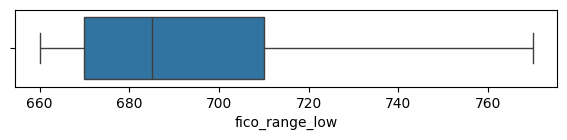

In [81]:
box(df, 'fico_range_low')

######[group] **`inq_last_6mths`** ✅

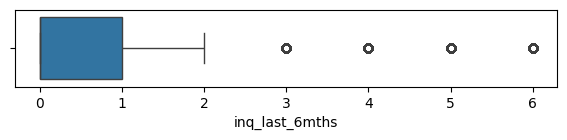

In [82]:
box(df, 'inq_last_6mths')

<Axes: xlabel='inq_last_6mths', ylabel='count'>

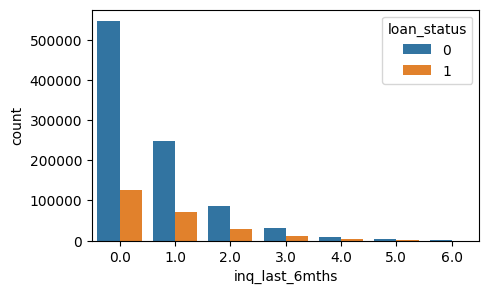

In [83]:
he = df.groupby(['inq_last_6mths', 'loan_status']).size().reset_index(name='count')
plt.figure(figsize=(5,3))
sns.barplot(data=he, x='inq_last_6mths', y='count', hue='loan_status')

In [84]:
inq_99 = np.percentile(df['inq_last_6mths'], 99)
print(f"99% ≤ {inq_99:,}")

99% ≤ 4.0


In [85]:
# df = df[df['inq_last_6mths'] <= 4]
# Không xóa, thử nhóm lại

In [86]:
def group_inq(x):
    if x == 0:
      return 0
    elif x <= 3:
      return 1    # 1 - 3
    else:
      return 2    # >= 4

df.loc[:, 'inq_group'] = df['inq_last_6mths'].apply(group_inq)

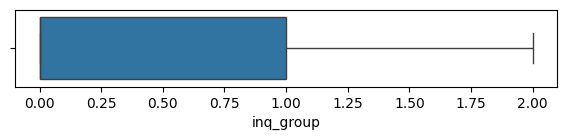

In [87]:
box(df, 'inq_group')

In [88]:
df.drop(columns='inq_last_6mths', inplace=True)
df.rename(columns=({'inq_group': 'inq_last_6mths'}), inplace=True)

<Axes: xlabel='inq_last_6mths', ylabel='count'>

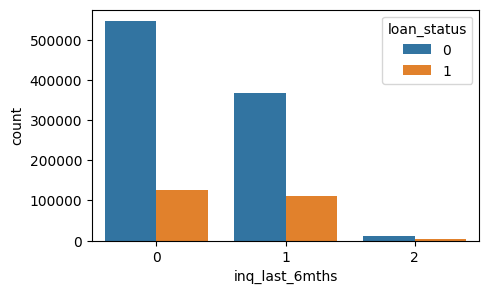

In [89]:
he = df.groupby(['inq_last_6mths', 'loan_status']).size().reset_index(name='count')
plt.figure(figsize=(5,3))
sns.barplot(data=he, x='inq_last_6mths', y='count', hue='loan_status')

######**`open_acc`**
ko log

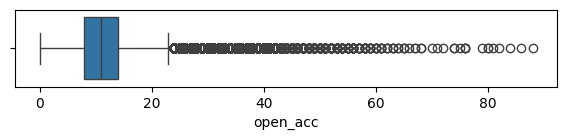

In [90]:
box(df, 'open_acc')

<Axes: xlabel='open_acc', ylabel='Count'>

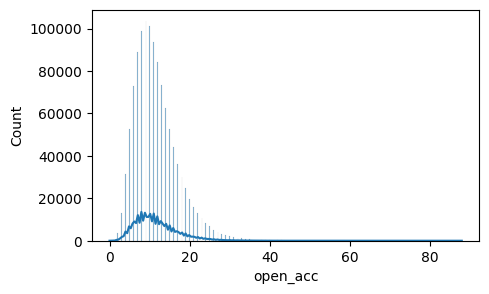

In [91]:
plt.figure(figsize=(5,3))
sns.histplot(df['open_acc'], kde=True)

In [92]:
open_99 = np.percentile(df['open_acc'], 99)
print(f"99% ≤ {open_99:,}")

99% ≤ 29.0


In [93]:
df = df[df['open_acc'] <= 29.0]

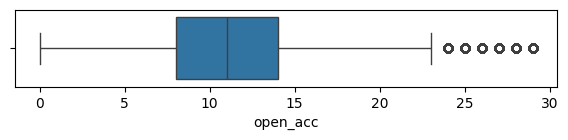

In [94]:
box(df, 'open_acc')

######**`revol_util`** ✅

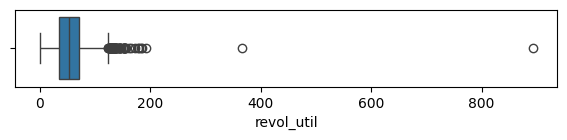

In [95]:
box(df, 'revol_util')

In [96]:
df = df[df['revol_util'] < 300]

In [97]:
print(f"99% ≤ {np.percentile(df['revol_util'], 99):,}")

99% ≤ 98.4


In [98]:
outliers(df, 'revol_util')

Q1: 35.5
Q2: 71.1
Ngưỡng dưới:  -17.89999999999999
Ngưỡng trên:  124.49999999999999


In [99]:
df = df[df['revol_util'] <= 124.49999999999999]

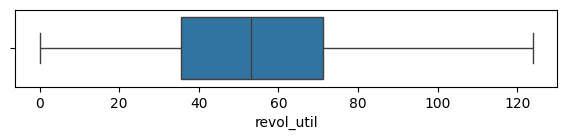

In [100]:
box(df, 'revol_util')

######**`avg_cur_bal`**
= tổng số dư hiện tại / số tk đang mở

không log

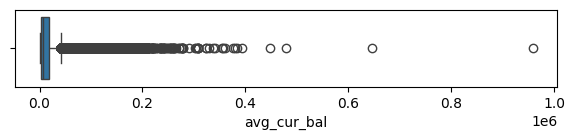

In [180]:
box(df, 'avg_cur_bal')
# Có 4 cái ngoại lai tách hẳn ra -> bỏ

In [101]:
df = df[df['avg_cur_bal'] < 400000]

In [102]:
print(f"99% ≤ {np.percentile(df['avg_cur_bal'], 99):,}")

99% ≤ 68,904.68999999994


In [103]:
df = df[df['avg_cur_bal'] <= 68904.59999999986]

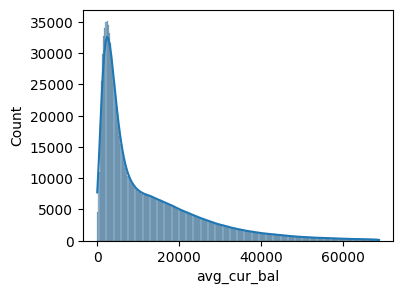

In [184]:
plt.figure(figsize=(4,3))
sns.histplot(x=df['avg_cur_bal'], kde=True)
plt.show()

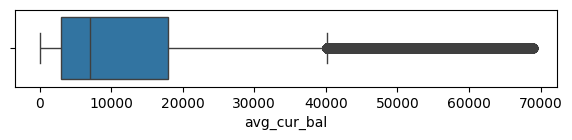

In [185]:
box(df, 'avg_cur_bal')

######**[log]`mo_sin_rcnt_tl`** ✅

In [104]:
print(f"99% ≤ {np.percentile(df['mo_sin_rcnt_tl'], 99):,}")

99% ≤ 42.0


In [105]:
df = df[df['mo_sin_rcnt_tl'] <= 42.0]

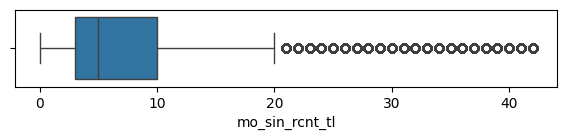

In [106]:
box(df, 'mo_sin_rcnt_tl')

<Axes: xlabel='mo_sin_rcnt_tl', ylabel='Count'>

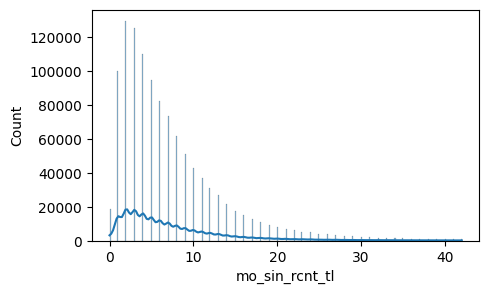

In [107]:
plt.figure(figsize=(5,3))
sns.histplot(x=df['mo_sin_rcnt_tl'], kde=True)

In [108]:
df['mo_log'] = np.log1p(df['mo_sin_rcnt_tl'])

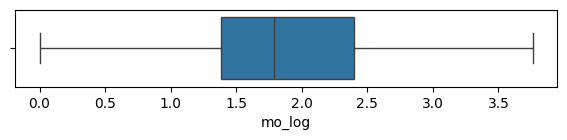

In [109]:
box(df, 'mo_log')

In [110]:
df.drop(columns=['mo_sin_rcnt_tl'], inplace=True)
df.rename(columns=({'mo_log': 'mo_sin_rcnt_tl'}), inplace=True)

<Axes: xlabel='mo_sin_rcnt_tl', ylabel='Count'>

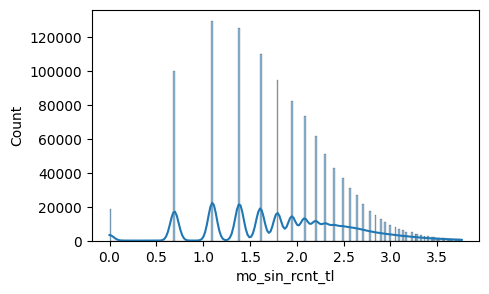

In [111]:
plt.figure(figsize=(5,3))
sns.histplot(x=df['mo_sin_rcnt_tl'], kde=True)

######**[log]`mort_acc`** ✅

In [112]:
print(f"99% ≤ {np.percentile(df['mort_acc'], 99):,}")

99% ≤ 8.0


In [113]:
# thông thường số tài khoản thế chấp có từ 1 - 5 là bình thường
# > 10 rất hiếm, có thể là khách VIP, hoặc là k rõ :>
# Thếm cái là 99% < 8, nới thêm 1 chút (lấy từ 10 đổ xuống để thêm rủi ro cho mô hình học)
df = df[df['mort_acc'] <= 10]

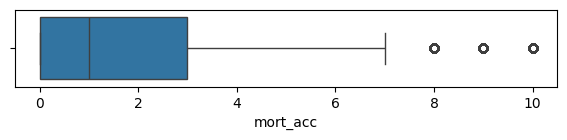

In [114]:
box(df, 'mort_acc')

In [115]:
df['mort_log'] = np.log1p(df['mort_acc'])

In [116]:
df.drop(columns=['mort_acc'], inplace=True)
df.rename(columns=({'mort_log': 'mort_acc'}), inplace=True)

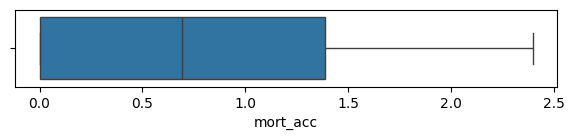

In [117]:
box(df, 'mort_acc')

######**`num_actv_bc_tl`**
ko log

In [118]:
print(f"99% ≤ {np.percentile(df['num_actv_bc_tl'], 99):,}")

99% ≤ 11.0


In [119]:
df = df[df['num_actv_bc_tl'] <= 11.0]

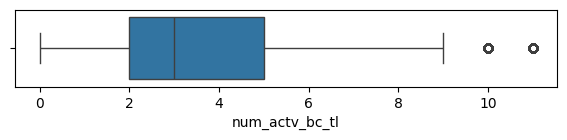

In [202]:
box(df, 'num_actv_bc_tl')

######**`[log] num_tl_op_past_12m`** ✅

In [120]:
print(f"99% ≤ {np.percentile(df['num_tl_op_past_12m'], 99):,}")

99% ≤ 8.0


In [121]:
df = df[df['num_tl_op_past_12m'] <= 8.0]

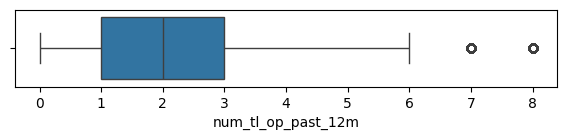

In [205]:
box(df, 'num_tl_op_past_12m')

In [122]:
df['num_log'] = np.log1p(df['num_tl_op_past_12m'])

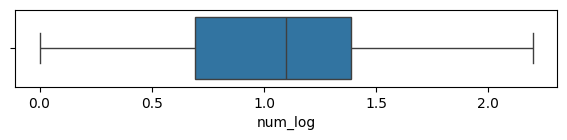

In [123]:
box(df, 'num_log')

In [124]:
df.drop(columns='num_tl_op_past_12m', inplace=True)
df.rename(columns=({'num_log': 'num_tl_op_past_12m'}), inplace=True)

# Chuẩn hóa + Chạy mô hình

Biến verification_status không cần encoding vì nó là biến phân loại **có mức độ**

Có thể chuẩn hóa cùng với các biến khác

### Lần 1

In [125]:
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [126]:
df_clean = df.copy()

In [127]:
df_clean.drop(columns=['total_rev_hi_lim', 'total_bc_limit'], inplace=True)
# Ý nghĩa 2 biến này đều là tổng số dư tín dụng, mà tùy người có ít nhiều tài khoản, người giàu nghèo khác nhau
# Nên biến này có thể phản ánh không đúng (gây nhiễu) nên không dùng

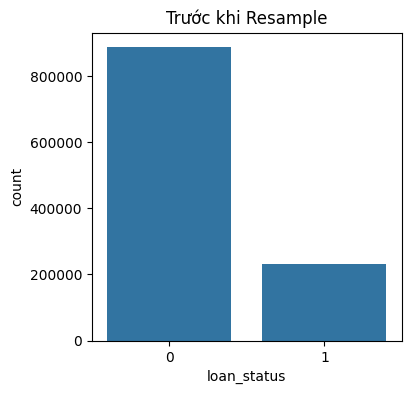

In [128]:
plt.figure(figsize=(4, 4))
sns.countplot(x='loan_status', data=df_clean)
plt.title('Trước khi Resample')
plt.show()

In [129]:
df_clean.shape

(1119122, 18)

In [130]:
# 1. Tách
X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]               # target: 0 = vỡ nợ, 1 = trả nợ

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Oversample: Tăng số lượng lớp thiểu số (lớp 0)
resampler = RandomOverSampler(sampling_strategy=0.7, random_state=42)  # đưa lớp 0 lên gần lớp 1
X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)

# 3. Chuẩn hóa
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 4. Huấn luyện mô hình
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train_res)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [131]:
# Lần tốt nhất từ trước đến h

# 5. Dự đoán trên tập test
y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[105077  72310]
 [ 16711  29727]]
              precision    recall  f1-score   support

           0       0.86      0.59      0.70    177387
           1       0.29      0.64      0.40     46438

    accuracy                           0.60    223825
   macro avg       0.58      0.62      0.55    223825
weighted avg       0.74      0.60      0.64    223825



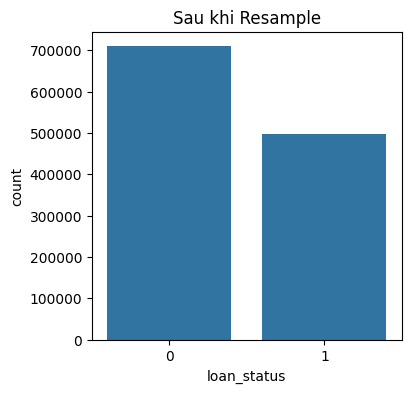

In [132]:
plt.figure(figsize=(4, 4))
sns.countplot(x=y_train_res)
plt.title('Sau khi Resample')
plt.show()

### Lần cuối

Với bài toán cho vay này, chi phí lớn nhất chính là trường hợp bạn dự đoán người vay sẽ trả được nợ (positive) nhưng thực chất họ vỡ nợ (false negative): bạn mất toàn bộ khoản vay. Ngược lại, nếu bạn từ chối một khách hàng tốt (false positive), bạn chỉ bỏ lỡ một cơ hội cho vay, thiệt hại về doanh thu có thể chấp nhận hơn.

Nên dùng Recall (ở đây là Recall của lớp “vỡ nợ”) để:

Giảm tối đa FN (“trả được” ⇢ “vỡ nợ”)

Bắt hết càng nhiều kẻ có khả năng vỡ nợ càng tốt

Tại sao: Giảm thiểu rủi ro mất vốn do dự đoán sai là ưu tiên hàng đầu.

In [133]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline  # pipeline hỗ trợ oversampling

# 1. Tách X, y
X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

# 2. Chia tập train - test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Chuẩn hóa
preprocessor = ColumnTransformer([
    ("num", RobustScaler(), X.columns)  # không còn phần cat
])

# 4. Pipeline tổng: gồm preprocessor, oversampling, và mô hình
pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("oversample", RandomOverSampler(sampling_strategy=0.7, random_state=42)),
    ("model", LogisticRegression(
        solver="saga", max_iter=1000, class_weight="balanced", random_state=42
    ))
])

# 5. GridSearch trên tham số C của LogisticRegression
param_grid = {
    "model__C": np.logspace(-4, 4, 10)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 6. Fit và predict
grid.fit(X_train, y_train)

y_pred = grid.best_estimator_.predict(X_test)
y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


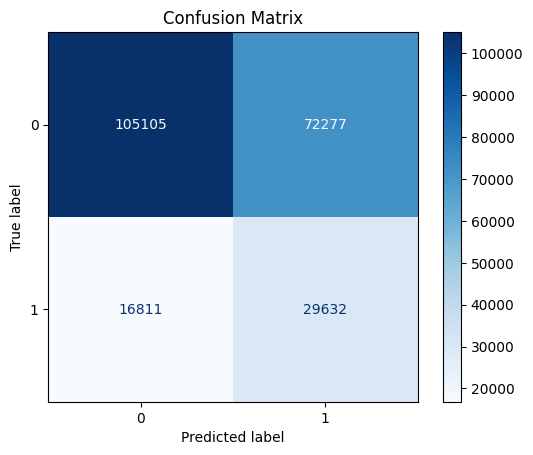

In [137]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

# Ma trận nhầm lẫn (sửa lại nhãn đi)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots()
disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [138]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.8621    0.5925    0.7023    177382
           1     0.2908    0.6380    0.3995     46443

    accuracy                         0.6020    223825
   macro avg     0.5764    0.6153    0.5509    223825
weighted avg     0.7436    0.6020    0.6395    223825



ROC-AUC Score: 0.6616


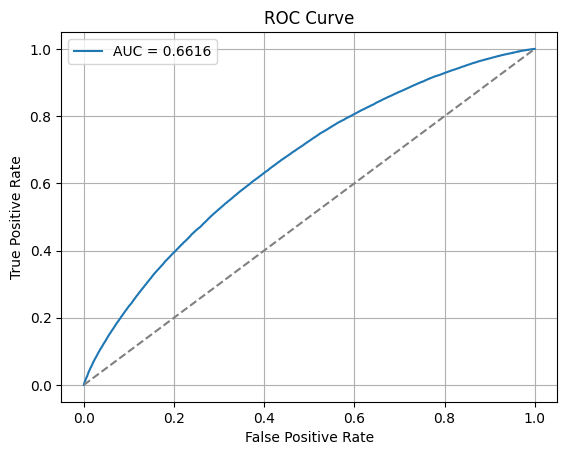

In [139]:
# Tính ROC AUC
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc:.4f}")

# Vẽ đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()